# Quantum State Tomography by Regularized Semidefinite Programming
___

## Problem

Let $\mathcal{H}$ be a $d$-dimensional Hilbert space, $Q_0, \dots, Q_M \in \mathbb{H}(\mathcal{H})$ Hermitian
observables, and $q_0, \dots, q_M \in \mathbb{R}$ their measured values. The states consistent with the
measurements form
$$
\operatorname{Adm}(Q, q) := \bigl\{ \pi \in \mathbb{H}_{\ge}(\mathcal{H}) \ : \ \operatorname{Tr}[Q_i \pi] = q_i, \ 0 \le i \le M \bigr\},
$$
with $\mathbb{H}_{\ge}(\mathcal{H})$ the positive semidefinite Hermitian operators. Setting $Q_0 = \mathrm{I}$,
$q_0 = 1$ imposes $\operatorname{Tr}\pi = 1$, which together with $\pi \succeq 0$ makes the set bounded.

Tomography is the problem of reconstructing a state from these measurements, posed as the least-squares fit
$$
\inf\left\{ \sum_{i=1}^{M} \bigl(\operatorname{Tr}[Q_i \pi] - q_i\bigr)^2 \ : \ \operatorname{Tr}\pi = 1,\ \pi \in \mathbb{H}_{\ge}(\mathcal{H}) \right\}
$$
[1, (6.1)]. We use exact data throughout: we fix $\rho$ and set $q_i = \operatorname{Tr}[Q_i \rho]$. The
infimum is then $0$ and its minimizers are exactly the elements of $\operatorname{Adm}(Q,q)$, so the fit
reduces to the semidefinite feasibility problem
$$
\min \bigl\{\, 0 \ : \ \pi \in \operatorname{Adm}(Q, q) \,\bigr\}
$$
[1, (6.2)], a semidefinite program with zero cost. Its optimal value carries no information; what matters
is which admissible $\pi$ a method returns. The admissible set is the intersection of the positive
semidefinite cone with an affine subspace of dimension $d^2 - M - 1$, so for $M + 1 < d^2$ it contains
infinitely many states and the data alone does not determine one. With noisy data
$\operatorname{Adm}(Q,q)$ may be empty and only the least-squares form survives.

## Regularization

Fix $\varepsilon > 0$ and a convex, superlinear, bounded-below $\varphi : [0, +\infty) \to \mathbb{R}$, and
minimize the spectral penalty instead of the zero cost:
$$
\mathcal{F}_\varepsilon(Q,q) \ = \ \min_\pi \bigl\{\, \varepsilon \operatorname{Tr}[\varphi(\pi)] \ : \ \pi \in \operatorname{Adm}(Q,q) \,\bigr\}.
$$
The factor $\varepsilon$ multiplies the whole objective, so the minimizer is the admissible state
minimizing $\operatorname{Tr}[\varphi(\pi)]$. Two choices are implemented in `sdplab`:

| $\varphi(t)$ | $\psi = \varphi^*$ | $\psi'(s)$ | selected state |
| --- | --- | --- | --- |
| $t(\log t - 1)$ | $e^{s}$ | $e^{s}$ | largest von Neumann entropy $S(\pi) = -\operatorname{Tr}[\pi \log \pi]$ |
| $t^2/2$ | $\max\{s,0\}^2/2$ | $\max\{s, 0\}$ | smallest Frobenius norm $\|\pi\|_F = \operatorname{Tr}[\pi^2]^{1/2}$ |

On unit-trace $\pi$, $\operatorname{Tr}[\pi(\log\pi - 1)] = -S(\pi) - 1$ and
$\operatorname{Tr}[\pi^2/2] = \tfrac12\|\pi\|_F^2$, which gives the two entries of the last column. Both are
verified numerically in Section 4.

## Dual problem

The regularized problem has the unconstrained differentiable dual
$$
\mathcal{D}_\varepsilon(\alpha) \ = \ \sum_{i=0}^{M} \alpha_i q_i \ - \ \varepsilon \operatorname{Tr}\left[ \psi\left( \frac{\sum_{i=0}^{M} \alpha_i Q_i - H}{\varepsilon} \right) \right], \qquad \alpha \in \mathbb{R}^{M+1},
$$
with $\psi = \varphi^*$ and $H$ the Hamiltonian, here $H = 0$. If some admissible state is strictly
positive, then $\mathcal{D}_\varepsilon(Q,q) = \mathcal{F}_\varepsilon(Q,q)$, a maximizer $\alpha^*$ exists,
and the primal minimizer is unique and given by [1, Theorem 2.5]
$$
\pi^* \ = \ \psi'\left( \frac{\sum_{i=0}^{M} \alpha^*_i Q_i - H}{\varepsilon} \right).
$$
By [1, Theorem 4.5], $\alpha$ maximizes $\mathcal{D}_\varepsilon$ if and only if the matrix produced by this
formula is admissible. Consequently
$$
\frac{\partial \mathcal{D}_\varepsilon}{\partial \alpha_j}(\alpha) \ = \ q_j - \operatorname{Tr}\left[ Q_j\, \psi'\left( \frac{\sum_i \alpha_i Q_i - H}{\varepsilon} \right) \right]
$$
is the constraint residual of the state recovered from $\alpha$, and $\|\nabla\mathcal{D}_\varepsilon\|_2$ is
the quantity plotted below. The dual value $\mathcal{D}_\varepsilon(\alpha)$ reports the size of the
regularization term and is not a measure of fit.

Every recovered state lies in
$$
S^\psi \ = \ \left\{ \pi \ : \ \pi = \psi'\Bigl(\textstyle\sum_{i=0}^M \alpha_i Q_i\Bigr), \ \alpha \in \mathbb{R}^{M+1} \right\},
$$
a family with $M+1$ parameters: Gibbs states of the measured observables for the entropy regularizer,
clipped positive parts for the quadratic one. Section 5 uses this.

## Role of $\varepsilon$

For $H = 0$ the parameter $\varepsilon$ does not change the optimal state. With
$\tilde\alpha = \alpha/\varepsilon$,
$$
\sum_{i} \alpha_i q_i - \varepsilon \operatorname{Tr}\left[ \psi\left( \frac{1}{\varepsilon}\sum_i \alpha_i Q_i \right) \right] \ = \ \varepsilon \left( \sum_i \tilde\alpha_i q_i - \operatorname{Tr}\left[ \psi\left( \sum_i \tilde\alpha_i Q_i \right) \right] \right),
$$
and the maximization is unconstrained, so every $\varepsilon$ solves the same problem: the maximizer scales
as $\alpha^*_\varepsilon = \varepsilon\,\tilde\alpha^*$ and $\pi^*$ is unchanged [1, Remark 6.2]. It remains a
free parameter of the numerics, and we set $\varepsilon = 1$ everywhere below.

## Notation in the code

$Q_i$ are the rows of the constraint operator `A`, the measured values are `q`, and the Hamiltonian $H$ is
`C = 0`. A solve returns the dual variable $\alpha$ as `info.dual`; applying $\psi'$ to it with
`primal_from_dual` gives the state, stored as `pi_scs`, `pi_q` and `pi_vn` for the three methods below.

## Libraries

`spacecore` provides the spaces and the optimizer:

- `Context('jax', dtype='complex128')` — array backend and dtype;
- `HermitianSpace(d)` — the $d \times d$ Hermitian matrices, where $\pi$ and $H$ live;
- `DenseCoordinateSpace((m,))` — where $q$ and $\alpha$ live;
- the JAX-compiled L-BFGS loop.

`sdplab` provides the program and its regularized dual:

- `DenseConstraintOp(Q, dom, cod)` — the map $\pi \mapsto (\operatorname{Tr}[Q_i \pi])_i$;
- `SDPProblem(C, A, b)` — the data $(H, \mathcal{A}, q)$;
- `EntropyReg` / `QuadraticReg` — the choice of $\varphi$;
- `RegularizedSDPDualFunctional(problem, reg)` — $\mathcal{D}_\varepsilon$, with `.bind(eps, normalized=True)`
  fixing $\varepsilon$ and `.primal_from_dual(alpha)` applying $\psi'$;
- `run_regularized_solver` — maximizes the dual; `run_cvxpy_solver` — solves the plain SDP through CVXPY.

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.linalg import expm
import optax
import jax
jax.config.update("jax_enable_x64", True)  # we solve the dual to ~1e-13; float32 would stall around 1e-4

# spacecore: the spaces the objects live in, and the compiled optimizer
from spacecore import HermitianSpace, DenseCoordinateSpace, Context

# sdplab: the SDP, the regularizers, and the smoothed dual
from sdplab import SDPProblem, DenseConstraintOp
from sdplab.solvers import run_cvxpy_solver, run_regularized_solver
from sdplab import RegularizedSDPDualFunctional as RegFunc, EntropyReg, QuadraticReg
from sdplab.special.pauli import generate_pauli_observables

## 1. Problem instance

We take $n = 4$ qubits, so $d = 16$, and $M = 5$ Pauli strings. The state has $d^2 - 1 = 255$ real
parameters against $6$ constraints, so the admissible set is $250$-dimensional.

Two constraint operators are built from the same strings. `A` holds the five traceless Paulis and is used
for the regularized dual, which imposes $\operatorname{Tr}\pi = 1$ internally (Sections 2 and 3). `A_I`
holds $Q_0 = \mathrm{I}$ as well and is used for CVXPY, which has no such mechanism: without that row the
feasible set of the plain SDP is unbounded and the returned matrix is not a state.

In [2]:
ctx = Context('jax', dtype='complex128')

observables_str = ["XXXI", "XIXY", "IYIZ", "ZIZI", "XYZI"]
n_qubit = len(observables_str[0])
dimension = 2 ** n_qubit

# Q[i] is the dense 16x16 matrix of the i-th Pauli string
Q = generate_pauli_observables(observables_str, ctx=ctx)

dom = HermitianSpace(dimension)                        # pi and H live here
cod = DenseCoordinateSpace((len(observables_str),))    # q and alpha live here
A = DenseConstraintOp(Q, dom, cod, ctx=ctx)            # (A pi)_i = Tr[Q_i pi]

# The same observables preceded by the trace row Q_0 = I, used for the CVXPY reference only.
Q_I = generate_pauli_observables(["I" * n_qubit] + observables_str, ctx=ctx)
cod_I = DenseCoordinateSpace((len(observables_str) + 1,))
A_I = DenseConstraintOp(Q_I, dom, cod_I, ctx=ctx)

A, A_I

(DenseConstraintOp(Herm(16) → ℂ^5, backend='jax', dtype=complex128),
 DenseConstraintOp(Herm(16) → ℂ^6, backend='jax', dtype=complex128))

### Data

We take $\rho = |v\rangle\langle v|$ with $|v\rangle$ a normalized complex Gaussian vector, a pure state of
rank $1$ and entropy $0$. The data is $q_i = \operatorname{Tr}[Q_i \rho]$, so $\rho \in \operatorname{Adm}(Q,q)$.

In [3]:
def random_pure_state(dimension, seed=None):
    """A Haar-random pure state |v><v| as a density matrix."""
    rng = np.random.default_rng(seed)
    vec = rng.normal(size=dimension) + 1j * rng.normal(size=dimension)
    vec = vec / np.linalg.norm(vec)
    rho = np.outer(vec, vec.conj())
    return (rho + rho.conj().T) / 2   # HermitianSpace checks Hermiticity exactly, so symmetrize


rho = ctx.asarray(random_pure_state(dimension, seed=1))

q = A.apply(rho)        # the five measured values
q_I = A_I.apply(rho)    # the same, preceded by q_0 = Tr[rho] = 1
C = ctx.ops.zeros((dimension, dimension))   # H = 0: tomography has no energy term

problem = SDPProblem(C, A, q)        # for the regularized dual
problem_I = SDPProblem(C, A_I, q_I)  # for CVXPY

for name, value in zip(observables_str, np.asarray(q).real):
    print(f"  Tr[{name} rho] = {value:+.6f}")
print("\nTr[rho] =", round(np.trace(np.asarray(rho)).real, 12),
      " rank =", int((np.linalg.eigvalsh(np.asarray(rho)) > 1e-9).sum()),
      " entropy =", 0.0)

  Tr[XXXI rho] = -0.346215
  Tr[XIXY rho] = +0.503766
  Tr[IYIZ rho] = +0.008403
  Tr[ZIZI rho] = -0.333414
  Tr[XYZI rho] = -0.059781

Tr[rho] = 1.0  rank = 1  entropy = 0.0


These five numbers and the trace are all the solvers receive. The remaining $250$ directions are
undetermined, and every state computed below fits the measurements exactly.

### Reference solution: SCS

CVXPY passes the zero-cost SDP to SCS, an operator-splitting solver. The formulation prefers no admissible
state over another, so the returned point is where the iteration stopped: admissible, and otherwise
uncharacterized.

In [4]:
pi_scs, alpha_scs = run_cvxpy_solver(problem_I, solver="SCS", verbose=True)

print("\nTr[pi_scs]          =", np.trace(np.asarray(pi_scs)).real)
print("||A pi_scs - q||_2  =", float(cod.norm(A.apply(pi_scs) - q)))
print("min eigenvalue      =", float(np.linalg.eigvalsh(np.asarray(pi_scs)).min()))

(CVXPY) Aug 24 05:24:16 PM: Your problem has 256 variables, 262 constraints, and 0 parameters.


(CVXPY) Aug 24 05:24:16 PM: It is compliant with the following grammars: DCP, DQCP


(CVXPY) Aug 24 05:24:16 PM: DCP verification time: 0.0003 seconds.


(CVXPY) Aug 24 05:24:16 PM: Expression tree has 7 nodes.


(CVXPY) Aug 24 05:24:16 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)


...

(CVXPY) Aug 24 05:24:16 PM: Problem status: optimal


(CVXPY) Aug 24 05:24:16 PM: Optimal value: 0.000e+00


(CVXPY) Aug 24 05:24:16 PM: Compilation took 2.019e-02 seconds


(CVXPY) Aug 24 05:24:16 PM: Solver (including time spent in interface) took 1.207e-02 seconds


                                     CVXPY                                     
                                     v1.9.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 256, constraints m: 534
cones: 	  z: primal zero / dual free vars: 6
	  s: psd vars: 528, ssize: 1
settings

## 2. Entropy regularization

For $\varphi(t) = t(\log t - 1)$ we have $\psi(s) = \psi'(s) = e^{s}$, so the recovered state is the Gibbs
state
$$
\pi^*_{\mathrm{vN}} \ = \ \frac{1}{Z}\exp\left( \frac{1}{\varepsilon} \sum_{i=1}^{M} \alpha^*_i Q_i \right), \qquad Z = \operatorname{Tr}\exp\left( \frac{1}{\varepsilon}\sum_{i=1}^{M} \alpha^*_i Q_i \right),
$$
of the effective Hamiltonian $-\sum_i \alpha^*_i Q_i$, and it has the largest von Neumann entropy in
$\operatorname{Adm}(Q,q)$.

**`normalized=True`.** The identity $Q_0 = \mathrm{I}$ is not a row of `A`; the flag imposes
$\operatorname{Tr}\pi = 1$ instead. For the entropy regularizer this is a rescaling:
$\exp(\alpha_0 \mathrm{I} + S) = e^{\alpha_0}\exp(S)$, so the trace multiplier is
$\theta = \varepsilon\log\operatorname{Tr}e^{S/\varepsilon}$ in closed form and the dual term becomes the
log-partition function $\varepsilon\log\operatorname{Tr}e^{S/\varepsilon}$. Without the flag the dual term is
$\varepsilon\operatorname{Tr}e^{S/\varepsilon}$, which overflows at small $\varepsilon$.

In [5]:
reg_vn = EntropyReg(dom)

# bind() freezes eps and the normalization onto the functional, so that the value, the gradient
# and the recovered state can never be evaluated at different settings by accident.
D_vn = RegFunc(problem, reg_vn).bind(eps_val=1.0, normalized=True)

info_vn = run_regularized_solver(
    D_vn,
    method="optax",        # the compiled spacecore/optax loop
    opt=optax.lbfgs(),     # the optimizer used in [1, Section 6]
    verbose=2,
    max_iter=10_000,
    tol=1e-12,             # tolerance on ||grad D_eps||, which is the constraint residual
)

pi_vn = D_vn.primal_from_dual(info_vn.dual)   # pi = psi'(slack / eps), normalized to unit trace

print("\nalpha*            =", np.round(np.asarray(info_vn.dual).real, 5))
print("Tr[pi_vn]         =", np.trace(np.asarray(pi_vn)).real)
print("||A pi_vn - q||_2 =", float(cod.norm(A.apply(pi_vn) - q)))
print("min eigenvalue    =", float(np.linalg.eigvalsh(np.asarray(pi_vn)).min()))

   iter               value               delta           grad_norm
-------------------------------------------------------------------
      0     +3.77258872e+00     +0.00000000e+00           6.989e-01
      8     +3.51976132e+00     +8.88178420e-16           1.332e-13
-------------------------------------------------------------------
status   : converged
iters    : 8  (nfev=9, njev=9, ls=8)
value    : +3.51976132e+00
grad_norm: 1.332e-13
compile: 0.38 s   execution: 0.00 s   avg/iter: 0.504 ms

alpha*            = [-0.36115  0.55524  0.00964 -0.34716 -0.06846]
Tr[pi_vn]         = 0.9999999999999999
||A pi_vn - q||_2 = 1.33214334990294e-13
min eigenvalue    = 0.013425341758217416


The recovered state reproduces the five measurements to $10^{-13}$ in eight iterations. Its smallest
eigenvalue is positive: an exponential has no zero eigenvalues, so a Gibbs state lies in the interior of
the positive semidefinite cone.

## 3. Quadratic ($L^2$) regularization

For $\varphi(t) = t^2/2$ on $t \ge 0$ we have $\psi(s) = \max\{s,0\}^2/2$ and $\psi'(s) = \max\{s,0\}$, so
$$
\pi^*_{Q} \ = \ \left( \frac{1}{\varepsilon} \sum_{i=1}^{M} \alpha^*_i Q_i - \theta \right)_{+}
$$
is the admissible state of smallest Frobenius norm, where $\theta \in \mathbb{R}$ is the multiplier enforcing
$\operatorname{Tr}\pi = 1$, i.e. the dual variable of the row $Q_0 = \mathrm{I}$ that `A` does not contain.


**`normalized=True` here.** Unlike the entropy case, the trace multiplier $\theta$ cannot be factored out of
a clip: the normalization is carried out by optimizing over $\theta$ at every function evaluation.


In [6]:
reg_q = QuadraticReg(dom)
D_q = RegFunc(problem, reg_q).bind(eps_val=1.0, normalized=True)

info_q = run_regularized_solver(
    D_q, method="optax", opt=optax.lbfgs(), verbose=2, max_iter=10_000, tol=1e-12,
)

pi_q = D_q.primal_from_dual(info_q.dual)

print("\nalpha*           =", np.round(np.asarray(info_q.dual).real, 5))
print("Tr[pi_q]         =", np.trace(np.asarray(pi_q)).real)
print("||A pi_q - q||_2 =", float(cod.norm(A.apply(pi_q) - q)))
print("min eigenvalue   =", float(np.linalg.eigvalsh(np.asarray(pi_q)).min()))
print("eigenvalues below 1e-9:", int((np.linalg.eigvalsh(np.asarray(pi_q)) < 1e-9).sum()))

   iter               value               delta           grad_norm
-------------------------------------------------------------------
      0     -3.12500000e-02     +0.00000000e+00           6.989e-01
     10     -4.67829023e-02     +6.93889390e-18           1.490e-15
-------------------------------------------------------------------
status   : converged
iters    : 10  (nfev=11, njev=11, ls=12)
value    : -4.67829023e-02
grad_norm: 1.490e-15
compile: 0.31 s   execution: 0.00 s   avg/iter: 0.287 ms

alpha*           = [-0.02453  0.03437  0.00055 -0.02373 -0.00393]
Tr[pi_q]         = 0.9999999999999998
||A pi_q - q||_2 = 1.4902243972013593e-15
min eigenvalue   = -6.389264035387361e-18
eigenvalues below 1e-9: 2


Two eigenvalues vanish, so this state lies on the boundary of the positive semidefinite cone, which the
Gibbs state of Section 2 cannot reach.

## 4. Comparison

Three admissible states are now available for the same data. We report $S(\pi)$, $\|\pi\|_F$, and the
numerical rank, which distinguishes the interior of the positive semidefinite cone from its boundary.

In [7]:
def von_neumann_entropy(pi):
    ev = np.clip(np.linalg.eigvalsh(np.asarray(pi)), 1e-300, None)
    return float(-np.sum(ev * np.log(ev)))


def frobenius(pi):
    return float(np.linalg.norm(np.asarray(pi)))


def numerical_rank(pi, tol=1e-9):
    return int((np.linalg.eigvalsh(np.asarray(pi)) > tol).sum())


solutions = [
    ("SCS (no regularization)", pi_scs),
    ("L2 regularization", pi_q),
    ("Entropy regularization", pi_vn),
]

print(f"{'Solution type':<24s} | {'Entropy S(pi)':>14s} | {'L2 norm':>10s} | {'rank':>5s}")
print(f"{'-'*24}-|-{'-'*14}-|-{'-'*10}-|-{'-'*5}")
for name, pi in solutions:
    print(f"{name:<24s} | {von_neumann_entropy(pi):14.6f} | {frobenius(pi):10.6f} | {numerical_rank(pi):5d}")

print(f"\n{'Solution type':<24s} | {'||A pi - q||':>12s} | {'||pi - rho||_F':>14s}")
print(f"{'-'*24}-|-{'-'*12}-|-{'-'*14}")
for name, pi in solutions:
    residual = float(cod.norm(A.apply(ctx.asarray(np.asarray(pi))) - q))
    print(f"{name:<24s} | {residual:12.2e} | {np.linalg.norm(np.asarray(pi) - np.asarray(rho)):14.6f}")

print("\n||pi_scs - pi_q||_F  =", float(np.linalg.norm(np.asarray(pi_scs) - np.asarray(pi_q))))
print("||pi_scs - pi_vn||_F =", float(np.linalg.norm(np.asarray(pi_scs) - np.asarray(pi_vn))))

Solution type            |  Entropy S(pi) |    L2 norm |  rank
-------------------------|----------------|------------|------
SCS (no regularization)  |       2.504940 |   0.307705 |    16
L2 regularization        |       2.479423 |   0.305885 |    14
Entropy regularization   |       2.519761 |   0.312683 |    16

Solution type            | ||A pi - q|| | ||pi - rho||_F
-------------------------|--------------|---------------
SCS (no regularization)  |     3.64e-09 |       0.950169
L2 regularization        |     1.49e-15 |       0.950941
Entropy regularization   |     1.33e-13 |       0.945074

||pi_scs - pi_q||_F  = 0.017667347285150757
||pi_scs - pi_vn||_F = 0.04607779911085148


Both characterizations hold: the $L^2$ row has the smallest Frobenius norm, the entropy row the largest
entropy, and each regularizer is worse than the other on the other's criterion. The SCS row lies between
them and satisfies no such property; its position is a consequence of the splitting iteration, not of the
formulation.

The rank column separates the regularizers qualitatively: the $L^2$ state has two zero eigenvalues, the
entropy state none. All three states are $\approx 0.95$ away from $\rho$ in Frobenius norm, so none of them
is a reconstruction of $\rho$ in any useful sense.

### Spectra

The two regularizers differ in which part of the spectrum they populate, so we plot the eigenvalues of the
three states together with those of $\rho$.

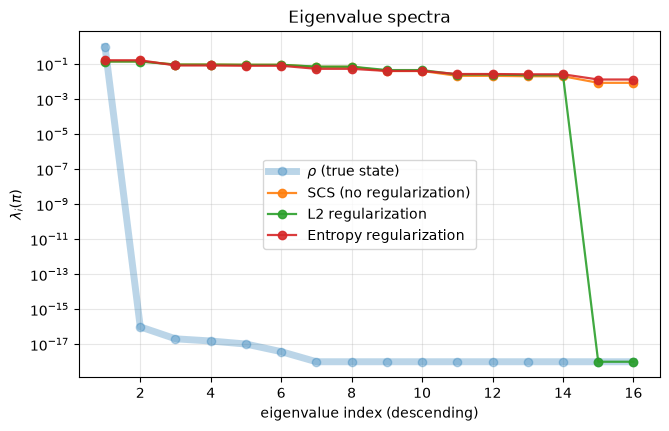

four smallest eigenvalues
  rho                      -7.61e-17  -4.31e-17  -1.46e-17  -9.91e-18
  SCS (no regularization)  +8.68e-03  +8.68e-03  +2.06e-02  +2.06e-02
  L2 regularization        -6.39e-18  +8.79e-19  +2.37e-02  +2.37e-02
  Entropy regularization   +1.34e-02  +1.34e-02  +2.67e-02  +2.67e-02


In [8]:
def plot_spectra(panels, suptitle, floor=1e-18):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for k, (name, pi) in enumerate(panels):
        ev = np.sort(np.linalg.eigvalsh(np.asarray(pi)))[::-1]
        # the true state is drawn thick and translucent, so a solution lying on top of it stays visible
        style = dict(lw=5, alpha=0.3) if k == 0 else dict(lw=1.6, alpha=0.9)
        ax.semilogy(np.arange(1, len(ev) + 1), np.clip(ev, floor, None), "o-", label=name, **style)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("eigenvalue index (descending)")
    ax.set_ylabel(r"$\lambda_i(\pi)$")
    ax.set_title(suptitle)
    ax.grid(alpha=0.3)
    ax.legend()
    return fig


plot_spectra([(r"$\rho$ (true state)", rho)] + solutions, "Eigenvalue spectra")
plt.show()

print("four smallest eigenvalues")
for name, pi in [("rho", rho)] + solutions:
    print(f"  {name:<24s} " + "  ".join(f"{v:+.2e}" for v in np.linalg.eigvalsh(np.asarray(pi))[:4]))

$\rho$ has one eigenvalue $1$ and fifteen equal to $0$, drawn at the floor of the log axis. The
reconstructions have spectra between $10^{-2}$ and $10^{-1}$, close to that of $\mathrm{I}/16$. At indices
15 and 16 the $L^2$ curve drops to the floor, where its two zero eigenvalues are, and the entropy curve
does not.

## 5. Exact recovery

The recovered state always lies in $S^\psi$, a family with $M+1 = 6$ parameters, while $\rho$ has
$d^2 - 1 = 255$. Exact recovery therefore requires one of two conditions.

**The constraints determine $\pi$.** If the $Q_i$ span $\mathbb{H}(\mathcal{H})$ — all $255$ non-identity
Pauli strings for $n$ qubits — then $\operatorname{Adm}(Q,q) = \{\rho\}$, every method returns $\rho$, and
the regularizer is irrelevant. This is full tomography: $\rho$ follows from inverting a linear map, at the
cost of $255$ measurements.

**The state lies in $S^\psi$.** Below the data is generated from a Gibbs state of the measured observables,
$$
\rho_{\mathrm{G}} \ = \ \frac{1}{Z}\exp\Bigl(\textstyle\sum_{i=1}^{M} c_i Q_i\Bigr), \qquad c \sim \mathcal{N}(0, 4\,\mathrm{I}_5),
$$
so $\rho_{\mathrm{G}} \in S^{\exp}$ by construction and its five coefficients are all that is unknown.
Entropy regularization recovers it from the five measurements; quadratic regularization, whose family
consists of clipped positive parts, does not. The instance is constructed in favour of the entropy
regularizer: what it demonstrates is membership in $S^\psi$, not a property of one regularizer over the
other.

In [9]:
c = 2.0 * np.random.default_rng(7).normal(size=len(observables_str))
generator = sum(ci * np.asarray(Q)[i] for i, ci in enumerate(c))
rho_gibbs = expm(generator)
rho_gibbs = rho_gibbs / np.trace(rho_gibbs).real
rho_gibbs = ctx.asarray((rho_gibbs + rho_gibbs.conj().T) / 2)

q_gibbs = A.apply(rho_gibbs)
problem_gibbs = SDPProblem(C, A, q_gibbs)


def solve_gibbs(regularizer, eps=1.0):
    D_eps = RegFunc(problem_gibbs, regularizer).bind(eps_val=eps, normalized=True)
    info = run_regularized_solver(
        D_eps, method="optax", opt=optax.lbfgs(), verbose=0, max_iter=10_000, tol=1e-12,
    )
    return D_eps.primal_from_dual(info.dual), info


pi_g_vn, info_g_vn = solve_gibbs(EntropyReg(dom))
pi_g_q, info_g_q = solve_gibbs(QuadraticReg(dom))

gibbs_solutions = [("L2 regularization", pi_g_q), ("Entropy regularization", pi_g_vn)]

print(f"{'Solution type':<24s} | {'Entropy S(pi)':>14s} | {'L2 norm':>10s} | {'rank':>5s} | {'||pi - rho_G||_F':>17s}")
print(f"{'-'*24}-|-{'-'*14}-|-{'-'*10}-|-{'-'*5}-|-{'-'*17}")
print(f"{'rho_G (true state)':<24s} | {von_neumann_entropy(rho_gibbs):14.6f} | {frobenius(rho_gibbs):10.6f} | {numerical_rank(rho_gibbs):5d} | {0.0:17.3e}")
for name, pi in gibbs_solutions:
    print(f"{name:<24s} | {von_neumann_entropy(pi):14.6f} | {frobenius(pi):10.6f} | {numerical_rank(pi):5d} | "
          f"{np.linalg.norm(np.asarray(pi) - np.asarray(rho_gibbs)):17.3e}")

print("\nL2 solution, four smallest eigenvalues     :", np.round(np.linalg.eigvalsh(np.asarray(pi_g_q))[:4], 15))
print("entropy solution, four smallest eigenvalues:", np.linalg.eigvalsh(np.asarray(pi_g_vn))[:4])

Solution type            |  Entropy S(pi) |    L2 norm |  rank |  ||pi - rho_G||_F
-------------------------|----------------|------------|-------|------------------
rho_G (true state)       |       1.945804 |   0.412342 |    16 |         0.000e+00
L2 regularization        |       1.903749 |   0.407778 |     8 |         3.831e-02
Entropy regularization   |       1.945804 |   0.412342 |    16 |         2.143e-13

L2 solution, four smallest eigenvalues     : [-0. -0. -0.  0.]
entropy solution, four smallest eigenvalues: [0.00077769 0.00077769 0.00078036 0.00078036]


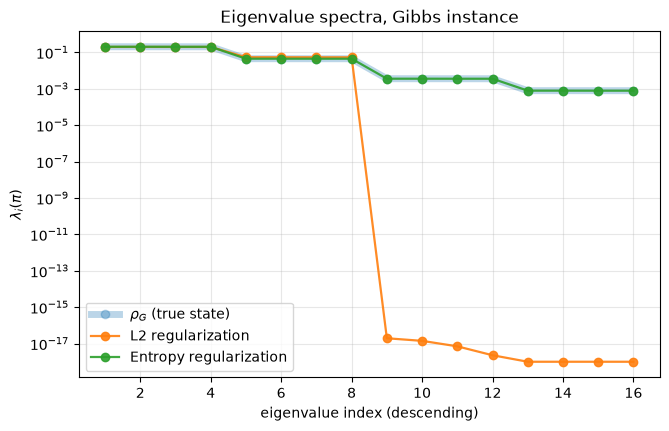

In [10]:
plot_spectra([(r"$\rho_G$ (true state)", rho_gibbs)] + gibbs_solutions,
             "Eigenvalue spectra, Gibbs instance")
plt.show()

Entropy regularization reproduces $\rho_{\mathrm{G}}$ to $2\cdot10^{-13}$ from five measurements, and its
spectrum coincides with that of $\rho_{\mathrm{G}}$. Quadratic regularization returns a state
$3.8\cdot10^{-2}$ away whose bottom eight eigenvalues are exactly zero, so half the spectrum lies on the
boundary of the cone. Both states reproduce all five measurements.

## References

[1] E. Caputo, A. Gerolin, N. Monina, P. Pelikh, L. Portinale, *Quantum thermodynamics and semidefinite
programming: regularization and algorithms*, [arXiv:2602.23144](https://arxiv.org/abs/2602.23144). Cited
definitions and theorem numbers refer to this paper; the tomography experiment is its Section 6.1.

## IMPORTANT

`spacecore` and `sdplab` are recently new libraries and are in alpha stage.
If you spotted a bug, please report an issue or send an email to pavlopelikh@gmail.com